In [1]:
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np
from pathlib import Path
from skimage.metrics import structural_similarity as ssim
from collections import Counter
import heapq
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms

In [2]:
test_data_folder = Path("test_data")

def load_data(folder) -> list:
    data_rgb = []

    for file in folder.glob("*.png"):
        image = Image.open(file).convert("RGB")
        data_rgb.append(image.copy())
        image.close()

    print("Count of loaded .png images:", len(data_rgb))
    return data_rgb

loaded_data_rgb = load_data(test_data_folder)


Count of loaded .png images: 71


In [3]:
class JPEGCodec:
    def __init__(self, block_size: int = 8, q_y: int = 10, q_c: int = 16):
        self.N = block_size
        self.C = self._dct_matrix(block_size)
        self.q_y = q_y
        self.q_c = q_c

    def _dct_matrix(self, N: int) -> np.ndarray:
        C = np.zeros((N, N), dtype=np.float64)
        for i in range(N):
            for j in range(N):
                alpha = np.sqrt(1 / N) if i == 0 else np.sqrt(2 / N)
                C[i, j] = alpha * np.cos(((2 * j + 1) * i * np.pi) / (2 * N))
        return C
    
    def _split_blocks(self, channel):
        H, W = channel.shape
        assert H % self.N == 0 and W % self.N == 0, "Image dimensions must be divisible by block size"
        return channel.reshape(
            H // self.N, self.N,
            W // self.N, self.N
        ).transpose(0, 2, 1, 3)

    def _merge_blocks(self, blocks):
        nb_h, nb_w, bh, bw = blocks.shape
        return blocks.transpose(0, 2, 1, 3).reshape(nb_h * bh, nb_w * bw)
    
    def _dct2(self, block):
        return self.C @ block @ self.C.T
    
    def _idct2(self, block):
        return self.C.T @ block @ self.C
    
    def transform_blocks(self, blocks):
        out = np.empty_like(blocks, dtype=np.float64)
        for i in range(blocks.shape[0]):
            for j in range(blocks.shape[1]):
                out[i, j] = self._dct2(blocks[i, j])
        return out
    
    def inverse_transform_blocks(self, blocks):
        out = np.empty_like(blocks, dtype=np.float64)
        for i in range(blocks.shape[0]):
            for j in range(blocks.shape[1]):
                out[i, j] = self._idct2(blocks[i, j])
        return out
    
    
    def transform(self, image: Image.Image) -> dict:
        image = image.convert("YCbCr")
        arr = np.asarray(image, dtype=np.uint8).astype(np.float64) - 128.0
        channels = []

        for c in range(3):
            blocks = self._split_blocks(arr[:, :, c])
            dct_blocks = self.transform_blocks(blocks)
            channels.append(dct_blocks)

        return {
            "ch1": channels[0],
            "ch2": channels[1],
            "ch3": channels[2]
        }

    def inverse_transform(self, encoded: dict) -> Image.Image:
        rec_channels = []

        for key in ["ch1", "ch2", "ch3"]:
            blocks = self.inverse_transform_blocks(encoded[key])
            rec_channels.append(self._merge_blocks(blocks))
        
        rec = np.stack(rec_channels, axis=-1)
        return Image.fromarray(np.clip(rec + 128.0, 0, 255).astype(np.uint8), mode="YCbCr").convert("RGB")
    

    # Quantization
    def quantize(self, transformed: dict) -> dict:
        quantized = {}
        for key in ["ch1", "ch2", "ch3"]:
            q = self.q_y if key == "ch1" else self.q_c
            quantized[key] = np.round(transformed[key] / q).astype(np.int32)
        return quantized
    
    def dequantize(self, quantized: dict) -> dict:
        dequantized = {}
        for key in ["ch1", "ch2", "ch3"]:
            q = self.q_y if key == "ch1" else self.q_c
            dequantized[key] = (quantized[key] * q).astype(np.float64)
        return dequantized
    
    # Zigzag scan
    def _zigzag_indices(self, N: int) -> np.ndarray:
        indices = []

        for s in range(2 * N - 1):
            if s % 2 == 0:
                for i in range(s, -1, -1):
                    j = s - i
                    if i < N and j < N:
                        indices.append((i, j))
            else:
                for j in range(s, -1, -1):
                    i = s - j
                    if i < N and j < N:
                        indices.append((i, j))
        return np.array(indices)
    
    def zigzag_scan(self, block):
        return np.array([block[i, j] for i, j in self._zigzag_indices(self.N)], dtype=np.int32)
    
    def zigzag_unscan(self, arr):
        block = np.zeros((self.N, self.N), dtype=np.int32)

        for idx, (i, j) in enumerate(self._zigzag_indices(self.N)):
            block[i, j] = arr[idx]
        return block
    
    # DC - DPCM
    def DPCM_encode(self, dc_values) -> np.ndarray:
        dc_values = np.asarray(dc_values, dtype=np.int32)

        diffs = np.empty_like(dc_values)
        previous = 0

        for i, dc in enumerate(dc_values):
            diffs[i] = dc - previous
            previous = dc

        return diffs
    
    def DPCM_decode(self, dc_diffs) -> np.ndarray:
        dc_diffs = np.asarray(dc_diffs, dtype=np.int32)

        dc_values = np.empty_like(dc_diffs)
        previous = 0

        for i, diff in enumerate(dc_diffs):
            dc_values[i] = diff + previous
            previous = dc_values[i]

        return dc_values
    
    # AC Run-length coding
    def RL_encode(self, arr):
        arr = np.asarray(arr, dtype=np.int32)
        symbols = []
        zero_run = 0

        for value in arr:
            value = int(value)

            if value == 0:
                zero_run += 1
            else:
                symbols.append((zero_run, value))
                zero_run = 0

        symbols.append(("EOB",))
        return symbols
    
    def RL_decode(self, symbols):
        ac = []
        for symbol in symbols:
            if symbol[0] == "EOB":
                break

            zero_run, value = symbol
            ac.extend([0] * zero_run)
            ac.append(value)

        target_length = self.N * self.N - 1
        ac.extend([0] * (target_length - len(ac)))
        return np.array(ac[:target_length], dtype=np.int32)

    # Entropy coding
    def entropy_encode(self, q_blocks):
        dc_values = []
        ac_symbols = []

        for i in range(q_blocks.shape[0]):
            for j in range(q_blocks.shape[1]):
                zz = self.zigzag_scan(q_blocks[i, j])

                dc_values.append(int(zz[0]))
                ac_symbols.append(self.RL_encode(zz[1:]))
        dc_diffs = self.DPCM_encode(dc_values)
        return {"dc_diffs": dc_diffs, "ac_symbols": ac_symbols, "shape": q_blocks.shape}

    def entropy_decode(self, encoded):
        nb_h, nb_w, _, _ = encoded["shape"]
        dc_values = self.DPCM_decode(encoded["dc_diffs"])
        ac_symbols = encoded["ac_symbols"]

        blocks = np.empty((nb_h, nb_w, self.N, self.N), dtype=np.int32)

        k = 0
        for i in range(nb_h):
            for j in range(nb_w):
                dc = dc_values[k]
                ac = self.RL_decode(ac_symbols[k])

                zz = np.concatenate(([dc], ac))
                blocks[i, j] = self.zigzag_unscan(zz)
                k += 1

        return blocks

    def encode(self, image: Image.Image) -> dict:
        transformed = self.transform(image)
        quantized = self.quantize(transformed)
        entropy_encoded = {key: self.entropy_encode(quantized[key]) for key in ["ch1", "ch2", "ch3"]}
        return entropy_encoded
    
    def decode(self, encoded: dict) -> Image.Image:
        entropy_decoded = {key: self.entropy_decode(encoded[key]) for key in ["ch1", "ch2", "ch3"]}
        dequantized = self.dequantize(entropy_decoded)
        output = self.inverse_transform(dequantized)
        return output

In [ ]:
class ResidualConvBlock(nn.Module):
    def __init__(
        self,
        in_ch,
        out_ch,
        kernel_size=3,
        stride=1,
        padding=1,
        dilation=1
    ):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_ch,
            out_ch,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            dilation=dilation,
            padding_mode="reflect"
        )

        self.conv2 = nn.Conv2d(
            out_ch,
            out_ch,
            kernel_size=kernel_size,
            stride=1,
            padding=padding,
            dilation=dilation,
            padding_mode="reflect"
        )

        self.relu = nn.LeakyReLU(0.1, inplace=True)

        if in_ch != out_ch:
            self.shortcut = nn.Conv2d(in_ch, out_ch, kernel_size=1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)

        out = out + identity
        out = self.relu(out)

        return out


class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1, skip_scale=0.7):
        super().__init__()

        self.skip_scale = skip_scale

        self.up = nn.ConvTranspose2d(
            in_ch,
            out_ch,
            kernel_size=2,
            stride=2
        )

        self.conv = ResidualConvBlock(
            in_ch=out_ch * 2,
            out_ch=out_ch,
            kernel_size=kernel_size,
            padding=padding
        )

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diff_y = x2.size(2) - x1.size(2)
        diff_x = x2.size(3) - x1.size(3)

        x1 = F.pad(
            x1,
            [
                diff_x // 2,
                diff_x - diff_x // 2,
                diff_y // 2,
                diff_y - diff_y // 2
            ]
        )

        x = torch.cat([self.skip_scale * x2, x1], dim=1)
        return self.conv(x)


class ResUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, base_features=32):
        super().__init__()

        f = base_features

        self.inc = ResidualConvBlock(
            in_channels,
            f,
            kernel_size=5,
            padding=2
        )

        self.down1 = nn.Sequential(
            nn.AvgPool2d(kernel_size=2, stride=2),
            ResidualConvBlock(f, f * 2)
        )

        self.down2 = nn.Sequential(
            nn.AvgPool2d(kernel_size=2, stride=2),
            ResidualConvBlock(f * 2, f * 4)
        )

        self.down3 = nn.Sequential(
            nn.AvgPool2d(kernel_size=2, stride=2),
            ResidualConvBlock(f * 4, f * 8)
        )

        self.up1 = UpBlock(f * 8, f * 4, skip_scale=0.7)
        self.up2 = UpBlock(f * 4, f * 2, skip_scale=0.7)
        self.up3 = UpBlock(f * 2, f, skip_scale=0.7)

        self.outc = nn.Conv2d(
            f,
            out_channels,
            kernel_size=3,
            padding=1,
            padding_mode="reflect"
        )

        self.res_scale = nn.Parameter(torch.tensor(0.2))

    def forward(self, x):
        decoded_input = x

        pad = 16
        x = F.pad(x, (pad, pad, pad, pad), mode="reflect")

        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        x = self.up1(x4, x3)
        x = self.up2(x, x2)
        x = self.up3(x, x1)

        residual = self.outc(x)
        residual = residual[..., pad:-pad, pad:-pad]

        enhanced = decoded_input + self.res_scale * residual

        if self.training:
            return enhanced

        return torch.clamp(enhanced, 0.0, 1.0)


# ============================================================
# 2. Utility functions
# ============================================================

def load_model(checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    base_features = checkpoint.get("base_features", 32)

    in_channels = 3
    out_channels = in_channels

    model = ResUNet(
        in_channels=in_channels,
        out_channels=out_channels,
        base_features=base_features
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    print(f"Loaded checkpoint from epoch {checkpoint.get('epoch', 'unknown')}")
    print(f"Validation loss: {checkpoint.get('val_loss', 'unknown')}")
    print(f"Base features: {base_features}")

    return model


def tensor_to_pil(tensor):
    """
    tensor: [1, C, H, W] in [0, 1]
    """
    tensor = tensor.squeeze(0).detach().cpu().clamp(0.0, 1.0)

    array = tensor.numpy()

    if array.shape[0] == 1:
        array = array[0]
        array = array * 255.0
        return Image.fromarray(array.astype(np.uint8), mode="L")

    array = np.transpose(array, (1, 2, 0))
    array = array * 255.0

    return Image.fromarray(array.astype(np.uint8), mode="RGB")


# ============================================================
# 3. Full-image inference
# ============================================================

@torch.no_grad()
def enhance_full_image(model, image_tensor, device):
    """
    Use this if the full image fits in GPU memory.

    image_tensor: [1, C, H, W]
    """
    image_tensor = image_tensor.to(device)
    enhanced = model(image_tensor)
    return enhanced


# ============================================================
# 5. Main
# ============================================================

def main():
    checkpoint_path = "../models/best_resunet_jpeg_artifact_removal_2.pth"

    img = loaded_data_rgb[44]

    codec = JPEGCodec(
        block_size=8,
        q_y=40,
        q_c=40*1.6,
    )

    encoded = codec.encode(img)
    decoded = codec.decode(encoded)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model = load_model(checkpoint_path, device)

    image = decoded

    to_tensor = transforms.ToTensor()

    image_tensor = to_tensor(image).unsqueeze(0)

    print(f"Input tensor shape: {image_tensor.shape}")

    enhanced_tensor = enhance_full_image(
        model=model,
        image_tensor=image_tensor,
        device=device
    )

    enhanced_image = tensor_to_pil(enhanced_tensor)
    # enhanced_image.save("enhanced_image.png")
    return enhanced_image

if __name__ == "__main__":
    enhanced_image = main()


Using device: cpu
Loaded checkpoint from epoch 79
Validation loss: 0.029711411458750565
Base features: 32
Input tensor shape: torch.Size([1, 3, 1344, 2032])


In [10]:
def MSE(original: Image.Image, reconstructed: Image.Image) -> float:
    arr_orig = np.asarray(original, dtype=np.float64)
    arr_rec = np.asarray(reconstructed, dtype=np.float64)
    mse = np.mean((arr_orig - arr_rec) ** 2)
    return mse

def PSNR(original: Image.Image, reconstructed: Image.Image) -> float:
    mse = MSE(original, reconstructed)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr = 10 * np.log10(max_pixel**2 / mse)
    return psnr

def SSIM(original: Image.Image, reconstructed: Image.Image) -> float:
    arr_orig = np.asarray(original, dtype=np.float64)
    arr_rec = np.asarray(reconstructed, dtype=np.float64)
    ssim_value = ssim(arr_orig, arr_rec, multichannel=True, channel_axis=2,data_range=255)
    return ssim_value

def entropy_symbols(symbols):
    counts = Counter(symbols)
    total = sum(counts.values())

    probs = np.array([count / total for count in counts.values()])
    return -np.sum(probs * np.log2(probs))


class HuffmanNode:
    def __init__(self, left=None, right=None):
        self.left = left
        self.right = right

def flatten_symbols(encoded):
    all_dc = []
    all_ac = []

    for key in ["ch1", "ch2", "ch3"]:
        all_dc.extend(encoded[key]["dc_diffs"].tolist())

        for block_symbols in encoded[key]["ac_symbols"]:
            all_ac.extend(block_symbols)

    return all_dc, all_ac

def build_huffman_codebook(symbols):
    counts = Counter(symbols)

    if len(counts) == 1:
        only_symbol = next(iter(counts))
        return {only_symbol: "0"}

    heap = []
    counter = 0

    for symbol, freq in counts.items():
        heapq.heappush(heap, (freq, counter, symbol))
        counter += 1

    while len(heap) > 1:
        freq1, _, left = heapq.heappop(heap)
        freq2, _, right = heapq.heappop(heap)

        node = HuffmanNode(left, right)
        heapq.heappush(heap, (freq1 + freq2, counter, node))
        counter += 1

    root = heap[0][2]
    codebook = {}

    def assign_codes(node, prefix):
        if isinstance(node, HuffmanNode):
            assign_codes(node.left, prefix + "0")
            assign_codes(node.right, prefix + "1")
        else:
            codebook[node] = prefix

    assign_codes(root, "")
    return codebook

def huffman_length(symbols, codebook):
    return sum(len(codebook[s]) for s in symbols)



In [34]:
image = loaded_data_rgb[2]
codec = JPEGCodec(
    block_size=8,
    q_y=40,
    q_c=40*1.6,
)
encoded = codec.encode(image)
decoded = codec.decode(encoded)
print("MSE:", MSE(image, decoded))
print("PSNR:", PSNR(image, decoded))
print("SSIM:", SSIM(image, decoded))

#enhanced
checkpoint_path = "../models/best_resunet_jpeg_artifact_removal_2.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = load_model(checkpoint_path, device)
to_tensor = transforms.ToTensor()
image_tensor = to_tensor(decoded).unsqueeze(0).to(device)
enhanced_tensor = enhance_full_image(model, image_tensor, device)
enhanced_image = tensor_to_pil(enhanced_tensor)
print("Enhanced MSE:", MSE(image, enhanced_image))
print("Enhanced PSNR:", PSNR(image, enhanced_image))
print("Enhanced SSIM:", SSIM(image, enhanced_image))



MSE: 62.55536868926541
PSNR: 30.168157727846257
SSIM: 0.8647744717108242
Loaded checkpoint from epoch 79
Validation loss: 0.029711411458750565
Base features: 32
Enhanced MSE: 44.26602350975659
Enhanced PSNR: 31.670098505298107
Enhanced SSIM: 0.9140049526616467


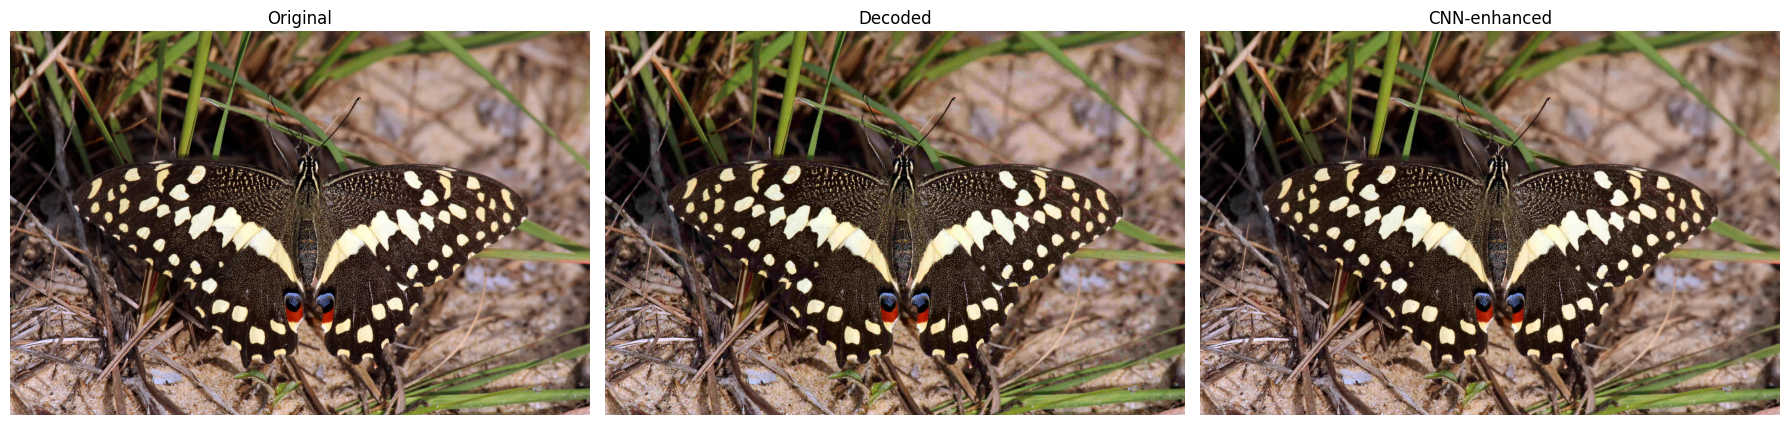

In [35]:
# Plots
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(decoded)
plt.title("Decoded")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(enhanced_image)
plt.title("CNN-enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()


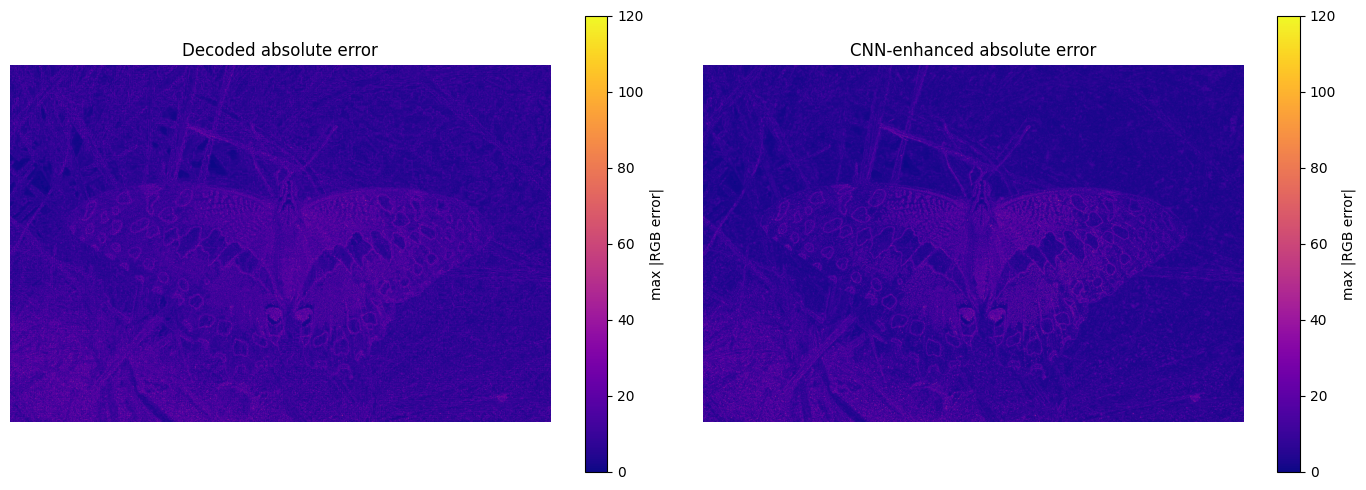

In [36]:
orig_arr = np.asarray(image, dtype=np.float32)
dec_arr = np.asarray(decoded, dtype=np.float32)
enh_arr = np.asarray(enhanced_image, dtype=np.float32)

decoded_error = np.max(np.abs(orig_arr - dec_arr), axis=2)
enhanced_error = np.max(np.abs(orig_arr - enh_arr), axis=2)

vmax = max(decoded_error.max(), enhanced_error.max())

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(decoded_error, cmap="plasma", vmin=0, vmax=vmax)
plt.title("Decoded absolute error")
plt.axis("off")
plt.colorbar(label="max |RGB error|")

plt.subplot(1, 2, 2)
plt.imshow(enhanced_error, cmap="plasma", vmin=0, vmax=vmax)
plt.title("CNN-enhanced absolute error")
plt.axis("off")
plt.colorbar(label="max |RGB error|")

plt.tight_layout()
plt.show()

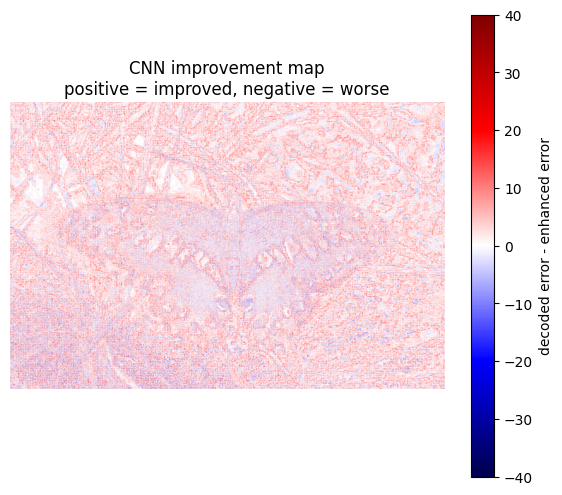

In [37]:
improvement = decoded_error - enhanced_error
limit = np.max(np.abs(improvement))

plt.figure(figsize=(7, 6))
plt.imshow(improvement, cmap="seismic", vmin=-limit, vmax=limit)
plt.title("CNN improvement map\npositive = improved, negative = worse")
plt.axis("off")
plt.colorbar(label="decoded error - enhanced error")
plt.show()

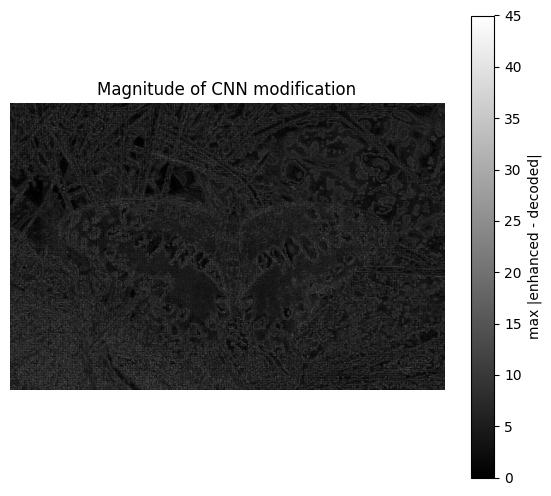

In [38]:
cnn_change = np.max(np.abs(enh_arr - dec_arr), axis=2)

plt.figure(figsize=(7, 6))
plt.imshow(cnn_change, cmap="gray")
plt.title("Magnitude of CNN modification")
plt.axis("off")
plt.colorbar(label="max |enhanced - decoded|")
plt.show()

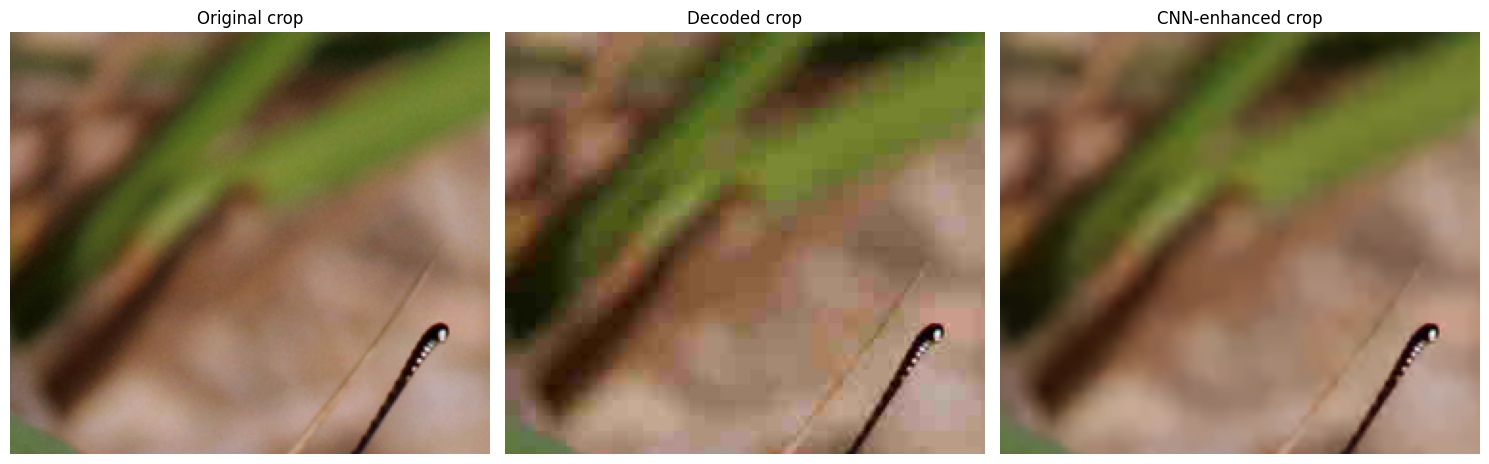

In [39]:
# Example crop coordinates
x1, y1 = 1000, 80
x2, y2 = 1250, 300

orig_crop = orig_arr[y1:y2, x1:x2]
dec_crop = dec_arr[y1:y2, x1:x2]
enh_crop = enh_arr[y1:y2, x1:x2]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(orig_crop.astype(np.uint8))
plt.title("Original crop")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(dec_crop.astype(np.uint8))
plt.title("Decoded crop")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(enh_crop.astype(np.uint8))
plt.title("CNN-enhanced crop")
plt.axis("off")

plt.tight_layout()
plt.show()

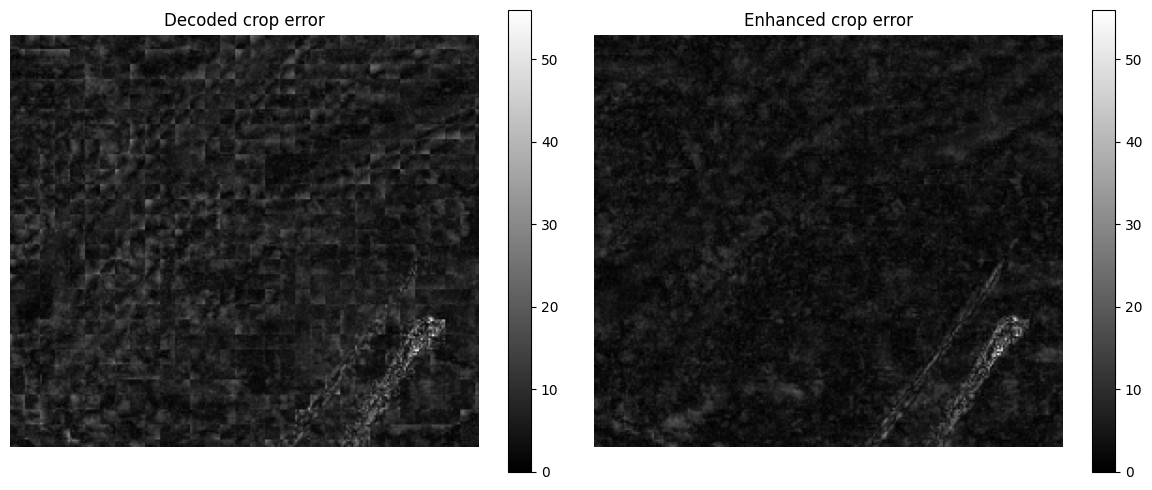

In [40]:
dec_crop_error = decoded_error[y1:y2, x1:x2]
enh_crop_error = enhanced_error[y1:y2, x1:x2]

vmax_crop = max(dec_crop_error.max(), enh_crop_error.max())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(dec_crop_error, cmap="gray", vmin=0, vmax=vmax_crop)
plt.title("Decoded crop error")
plt.axis("off")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(enh_crop_error, cmap="gray", vmin=0, vmax=vmax_crop)
plt.title("Enhanced crop error")
plt.axis("off")
plt.colorbar()

plt.tight_layout()
plt.show()

Decoded:
MSE: 62.55536868926541
PSNR: 30.168157727846257
SSIM: 0.8647744717108242

CNN-enhanced:
MSE: 44.26602350975659
PSNR: 31.670098505298107
SSIM: 0.9140049526616467


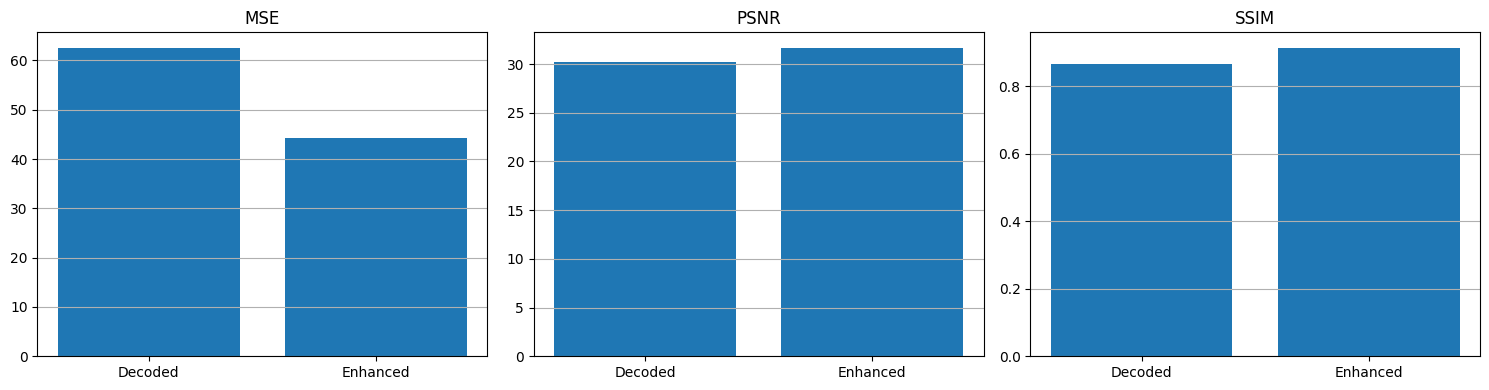

In [41]:
mse_decoded = MSE(image, decoded)
psnr_decoded = PSNR(image, decoded)
ssim_decoded = SSIM(image, decoded)

mse_enhanced = MSE(image, enhanced_image)
psnr_enhanced = PSNR(image, enhanced_image)
ssim_enhanced = SSIM(image, enhanced_image)

print("Decoded:")
print("MSE:", mse_decoded)
print("PSNR:", psnr_decoded)
print("SSIM:", ssim_decoded)

print("\nCNN-enhanced:")
print("MSE:", mse_enhanced)
print("PSNR:", psnr_enhanced)
print("SSIM:", ssim_enhanced)

metrics = ["MSE", "PSNR", "SSIM"]
decoded_values = [mse_decoded, psnr_decoded, ssim_decoded]
enhanced_values = [mse_enhanced, psnr_enhanced, ssim_enhanced]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, d, e in zip(axes, metrics, decoded_values, enhanced_values):
    ax.bar(["Decoded", "Enhanced"], [d, e])
    ax.set_title(metric)
    ax.grid(axis="y")

plt.tight_layout()
plt.show()